... (TREINO) A fitar o MinMaxScaler.
TREINO
Classes do Alvo encontradas (em MAIÚSCULAS): ['HIGH', 'LOW', 'MEDIUM', 'NONE', 'VERY_HIGH']
... (TESTE) A aplicar o MinMaxScaler já treinado.
Shape final do Treino (X_train): (6812, 33)
Número de features: 33
A calcular o Cross-Validation do VotingClassifier...


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   35.1s finished



Validação concluída em 0.59 minutos.
Score ANTERIOR (v16, Stacking): 0.81489 (Kaggle: 0.83555)
MELHOR ACCURACY (Voting v53): 0.81019
Ficheiro 'submission_v53_VOTING.csv' criado com sucesso!
   RowId Speed_Diff
0      1       None
1      2     Medium
2      3       None
3      4       High
4      5        Low

   RELATÓRIO DETALHADO E VISUALIZAÇÃO (VOTING CLASSIFIER)
[SUCESSO] Imagem 'matriz_confusao_voting_laranja.png' guardada.

--- Métricas de Classificação (Validação Cruzada) ---
              precision  recall  f1-score  support
HIGH          0.779      0.777   0.778     1063   
LOW           0.711      0.717   0.714     1419   
MEDIUM        0.789      0.776   0.783     1651   
NONE          0.891      0.914   0.902     2200   
VERY_HIGH     0.869      0.802   0.834      479   
accuracy      0.810      0.810   0.810        0   
macro avg     0.808      0.797   0.802     6812   
weighted avg  0.810      0.810   0.810     6812   

[INFO] Tabela exportada para CSV.


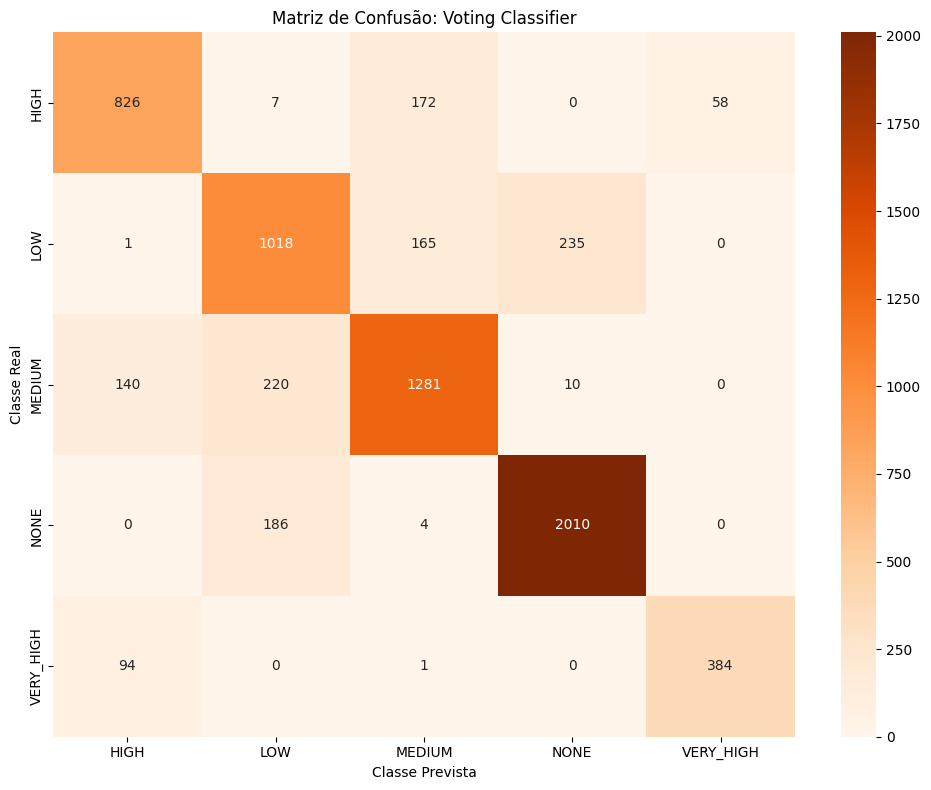

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import warnings
import time 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')
warnings.filterwarnings('ignore', category=Warning) 

# --- 1. FUNÇÃO DE PRÉ-PROCESSAMENTO (IDÊNTICA AO v16) ---
def formatar_celula(series_coluna):
    s = series_coluna.astype(str).replace('NULL', pd.NA)
    s = s.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
    s = s.str.upper()
    s = s.str.replace(r'[^A-Z0-9]+', '_', regex=True)
    s = s.str.strip('_')
    s = s.replace('', pd.NA)
    return s

def preprocessar_dados(df, colunas_scaler_treinadas=None, scaler=None):
    if 'RowId' not in df.columns and 'AVERAGE_SPEED_DIFF' not in df.columns:
        df_final_row_ids = np.arange(1, len(df) + 1)
    else:
        df_final_row_ids = None
    cols_to_transform = ['AVERAGE_CLOUDINESS', 'AVERAGE_RAIN']
    for col in cols_to_transform:
        if col in df.columns:
            df[col] = formatar_celula(df[col])
    cols_to_drop_base = ['city_name', 'AVERAGE_RAIN', 'AVERAGE_PRECIPITATION', 'record_date']
    try:
        df['record_date_dt'] = pd.to_datetime(df['record_date'], format='mixed', dayfirst=True)
        df['Hora_sin'] = np.sin(2 * np.pi * df['record_date_dt'].dt.hour/24)
        df['Hora_cos'] = np.cos(2 * np.pi * df['record_date_dt'].dt.hour/24)
        df['Mes_sin'] = np.sin(2 * np.pi * df['record_date_dt'].dt.month/12)
        df['Mes_cos'] = np.cos(2 * np.pi * df['record_date_dt'].dt.month/12)
        df['DIA_SEMANA'] = df['record_date_dt'].dt.dayofweek
        df['IS_WEEKEND'] = df['DIA_SEMANA'].isin([5, 6]).astype(int)
        rush_hours = [7, 8, 9, 17, 18, 19]
        df['IS_RUSH_HOUR'] = df['record_date_dt'].dt.hour.isin(rush_hours).astype(int)
        df = df.drop(columns=['record_date_dt'])
    except KeyError:
        pass
    cols_existentes_drop = [col for col in cols_to_drop_base if col in df.columns]
    df = df.drop(columns=cols_existentes_drop)
    if 'AVERAGE_CLOUDINESS' in df.columns:
        df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].replace('NAN', np.nan)
        df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].fillna('NONE')
    cols_to_onehot = ['LUMINOSITY', 'AVERAGE_CLOUDINESS', 'DIA_SEMANA']
    for col in cols_to_onehot:
        if col in df.columns:
            prefix = col[:3].upper()
            if col == 'DIA_SEMANA': prefix = 'DAY'
            dummies = pd.get_dummies(df[col], prefix=prefix, dtype=int, sparse=False)
            df = pd.concat([df, dummies], axis=1)
            df = df.drop(col, axis=1)
    cols_to_normalize = ['AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF', 'AVERAGE_FREE_FLOW_TIME','AVERAGE_TEMPERATURE', 'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY','AVERAGE_WIND_SPEED', 'IS_WEEKEND', 'IS_RUSH_HOUR','Hora_sin', 'Hora_cos', 'Mes_sin', 'Mes_cos']
    cols_existentes_normalize = [col for col in cols_to_normalize if col in df.columns]
    if scaler is None:
        print("... (TREINO) A fitar o MinMaxScaler.")
        scaler = MinMaxScaler()
        if cols_existentes_normalize:
            df[cols_existentes_normalize] = scaler.fit_transform(df[cols_existentes_normalize])
        return df, scaler, cols_existentes_normalize, df_final_row_ids
    else:
        print("... (TESTE) A aplicar o MinMaxScaler já treinado.")
        cols_para_scaler_teste = [col for col in colunas_scaler_treinadas if col in df.columns]
        if cols_para_scaler_teste:
            df[cols_para_scaler_teste] = scaler.transform(df[cols_para_scaler_teste])
        return df, None, None, df_final_row_ids

# --- 2. CARREGAR DADOS ---
df_train = pd.read_csv("training_data.csv", delimiter=",", encoding="latin-1")
df_test = pd.read_csv("test_data.csv", delimiter=",", encoding="latin-1")
y_train_raw = df_train.pop('AVERAGE_SPEED_DIFF')
test_row_ids = np.arange(1, len(df_test) + 1)

# --- 3. PRÉ-PROCESSAMENTO (TREINO) ---
X_train, scaler, colunas_scaler, _ = preprocessar_dados(df_train)
print("TREINO")
le = LabelEncoder()
y_train_formatado = formatar_celula(y_train_raw).replace('NAN', 'NONE').fillna('NONE')
y_train_encoded = le.fit_transform(y_train_formatado)
print(f"Classes do Alvo encontradas (em MAIÚSCULAS): {list(le.classes_)}")

# --- 4. PRÉ-PROCESSAMENTO (TESTE) ---
X_test, _, _, _ = preprocessar_dados(df_test, colunas_scaler_treinadas=colunas_scaler, scaler=scaler)

# --- 5. ALINHAMENTO DE COLUNAS ---
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_train = X_train.reindex(columns=X_test.columns, fill_value=0)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)
print(f"Shape final do Treino (X_train): {X_train.shape}")
print(f"Número de features: {X_train.shape[1]}") # 33

# --- 6. VALIDAÇÃO DO ENSEMBLE (Voting) ---
# Votante 1: XGB (v11)
clf1 = XGBClassifier(
    learning_rate=0.08, max_depth=5, n_estimators=100,
    subsample=0.7, colsample_bytree=0.9,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)
# Votante 2: LGBM (v12)
clf2 = LGBMClassifier(
    subsample=0.9, num_leaves=50, n_estimators=200,
    learning_rate=0.01, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
# Votante 3: RandomForest 
clf3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10, 
    random_state=42, 
    n_jobs=-1
)

# Criar o Ensemble 
# voting='hard' -> Voto da Maioria
eclf1 = VotingClassifier(
    estimators=[
        ('xgb', clf1), 
        ('lgbm', clf2), 
        ('rf', clf3)
    ], 
    voting='hard',
    n_jobs=-1
)

print("A calcular o Cross-Validation do VotingClassifier...")
start_time = time.time()
scores = cross_val_score(eclf1, X_train, y_train_encoded, cv=5, scoring='accuracy', n_jobs=1, verbose=1)
end_time = time.time()

print(f"\nValidação concluída em {(end_time - start_time) / 60:.2f} minutos.")
print(f"Score ANTERIOR (v16, Stacking): 0.81489 (Kaggle: 0.83555)")
print(f"MELHOR ACCURACY (Voting v53): {np.mean(scores):.5f}")

# --- 7. TREINO DO MODELO FINAL (Voting) ---
eclf1.fit(X_train, y_train_encoded)

# --- 8. PREVISÃO E SUBMISSÃO ---
y_pred_encoded = eclf1.predict(X_test)
y_pred_labels_upper = le.inverse_transform(y_pred_encoded)
y_pred_labels_final = pd.Series(y_pred_labels_upper).str.title()

submission_df = pd.DataFrame({
    'RowId': test_row_ids,
    'Speed_Diff': y_pred_labels_final
})

submission_df.to_csv('submission_v53_VOTING.csv', index=False)

print("Ficheiro 'submission_v53_VOTING.csv' criado com sucesso!")
print(submission_df.head())

print("\n" + "="*80)
print("   RELATÓRIO DETALHADO E VISUALIZAÇÃO (VOTING CLASSIFIER)")
print("="*80)

# 1. Gerar Previsões de Validação Cruzada
y_pred_cv = cross_val_predict(eclf1, X_train, y_train_encoded, cv=5, n_jobs=-1)

# 2. Matriz de Confusão
cm = confusion_matrix(y_train_encoded, y_pred_cv)
classes_nomes = list(le.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes_nomes, yticklabels=classes_nomes)
plt.title('Matriz de Confusão: Voting Classifier')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.tight_layout()
plt.savefig('matriz_confusao_voting_laranja.png', dpi=300)
print("[SUCESSO] Imagem 'matriz_confusao_voting_laranja.png' guardada.")

# 3. Relatório de Métricas 
print("\n--- Métricas de Classificação (Validação Cruzada) ---")
report_dict = classification_report(y_train_encoded, y_pred_cv, target_names=classes_nomes, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

# Formatação: Arredondar e limpar
df_report = df_report.round(3)
df_report['support'] = df_report['support'].astype(int)

# Imprimir alinhado à esquerda
print(df_report.to_string(justify='left'))

# 5. Exportar CSVs
df_report.to_csv('relatorio_metricas_votinng.csv')
print("\n[INFO] Tabela exportada metricas para CSV.")